Stitched 2 split(s) -> shape (541909, 8)
Shape: (541909, 8)
Duplicates: 5,268

Missing values:
             n_missing    pct
Description       1454   0.27
CustomerID      135080  24.93

Numeric summary:
                count          mean          std       min       25%       50%  \
Quantity    541909.0      9.552250   218.081158 -80995.00      1.00      3.00   
UnitPrice   541909.0      4.611114    96.759853 -11062.06      1.25      2.08   
CustomerID  406829.0  15287.690570  1713.600303  12346.00  13953.00  15152.00   

                 75%      max  
Quantity       10.00  80995.0  
UnitPrice       4.13  38970.0  
CustomerID  16791.00  18287.0  
Date range: 2010-12-01 08:26:00  ->  2011-12-09 12:50:00
Sales rows: 524,878 | Cancel/return rows: 10,587 | Anonymous revenue share: 16.5%
     Total revenue (£): 10,642,111
              Invoices: 19,960
       Unique products: 3,922
  Identified customers: 4,338
   Avg order value (£): 533.17


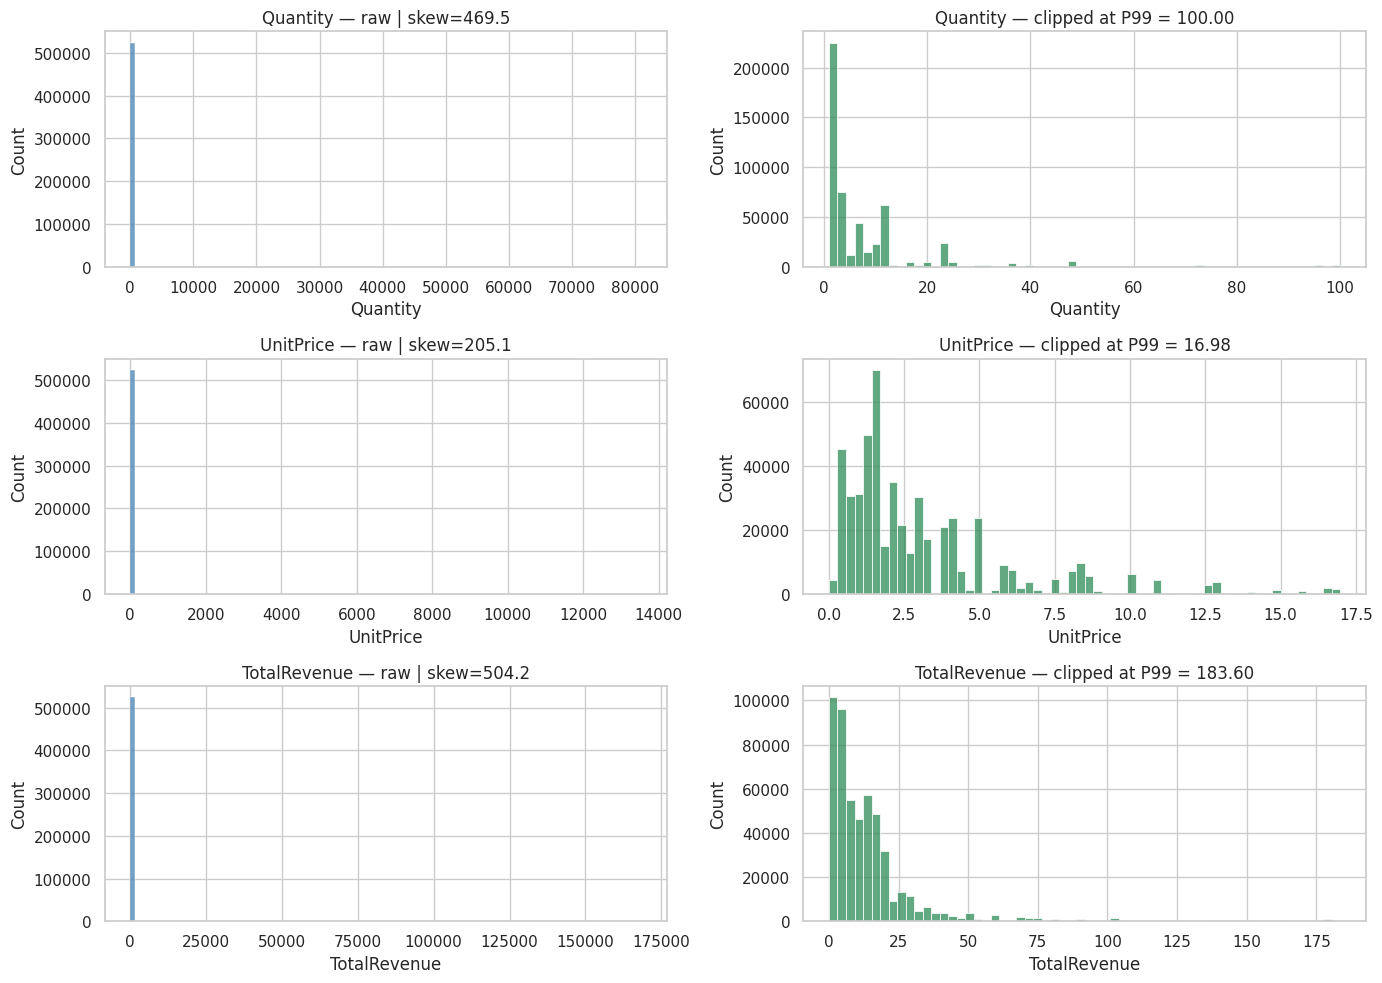

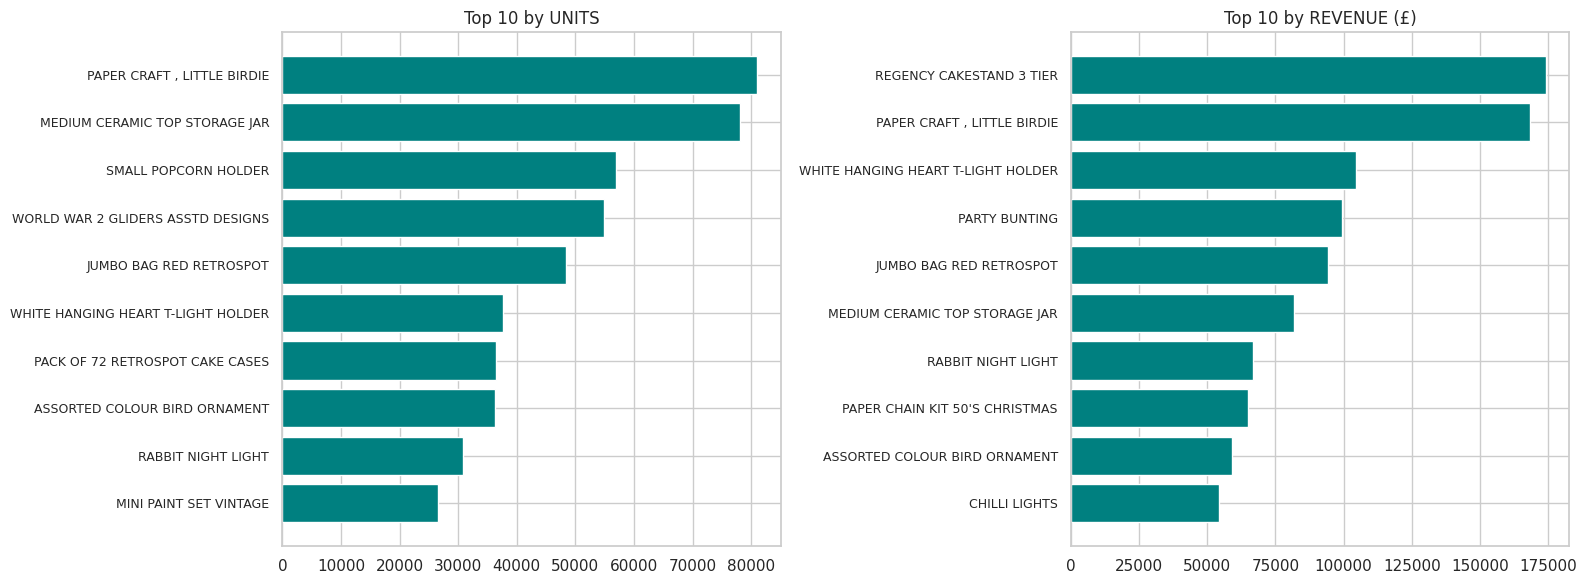

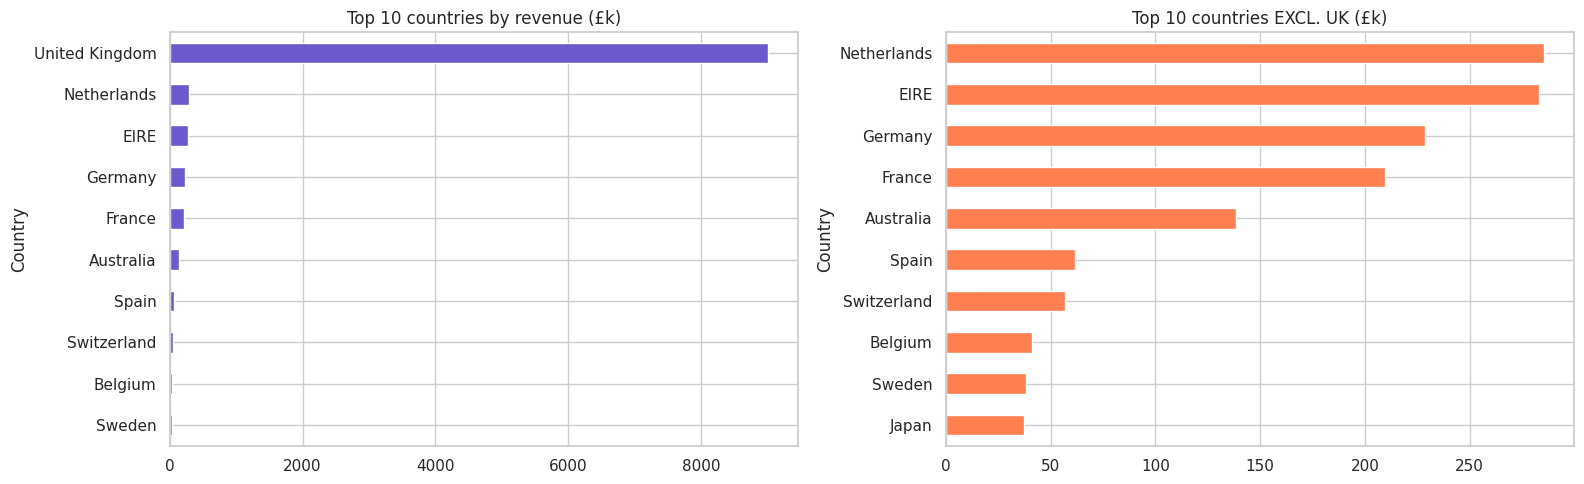

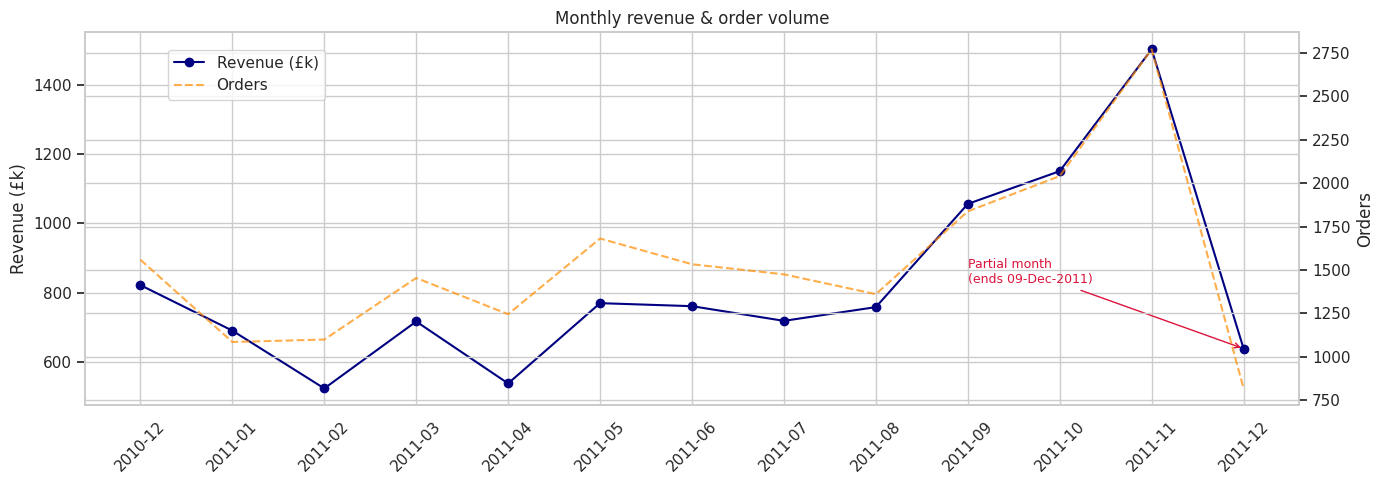

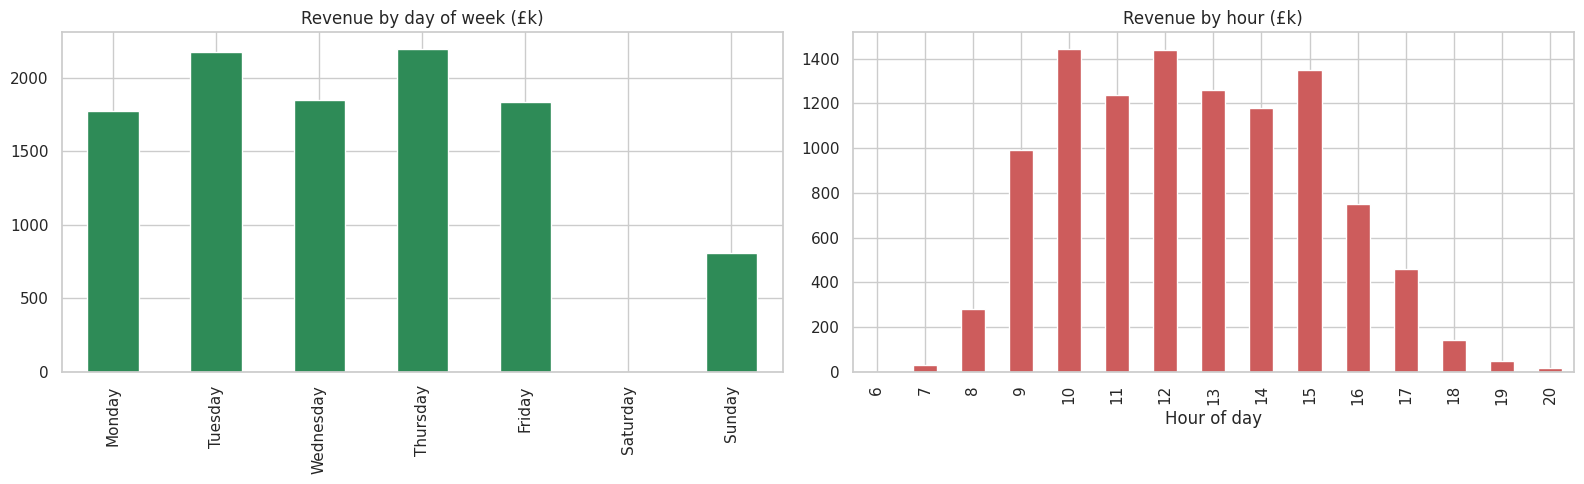

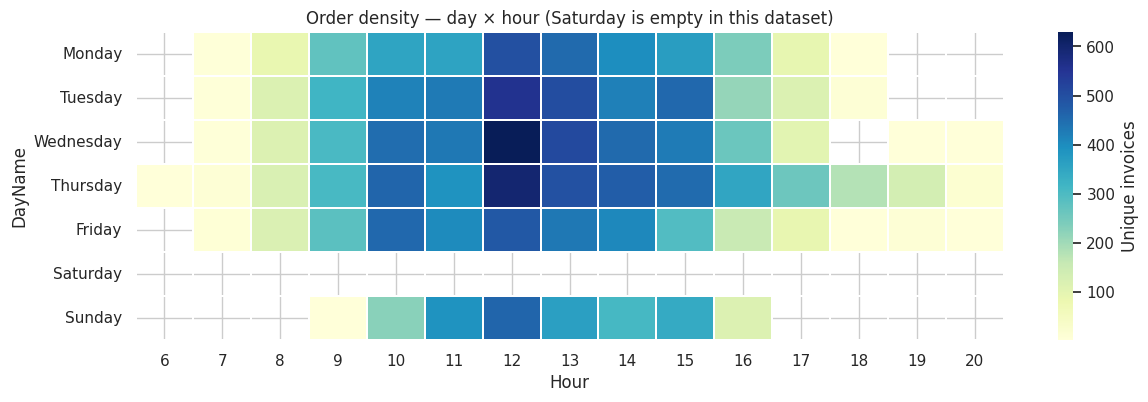


Cancellation share of raw rows: 1.95%
Top 5 returned products (units):
 Description
PAPER CRAFT , LITTLE BIRDIE       80995
MEDIUM CERAMIC TOP STORAGE JAR    74494
nan                               46156
printing smudges/thrown away      19200
Unsaleable, destroyed.            15644
Name: ReturnQty, dtype: int64


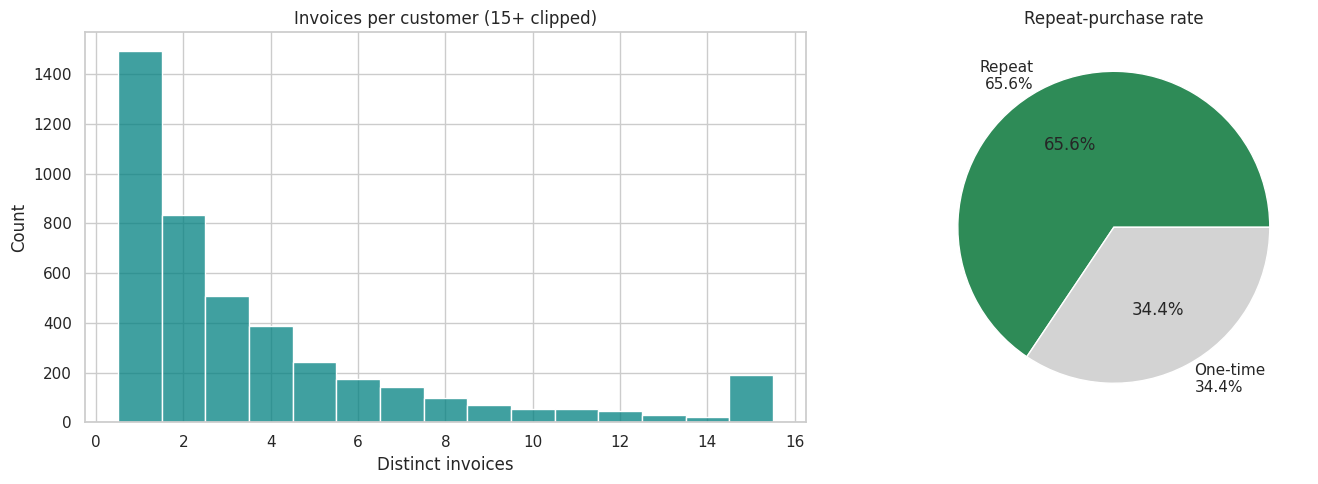

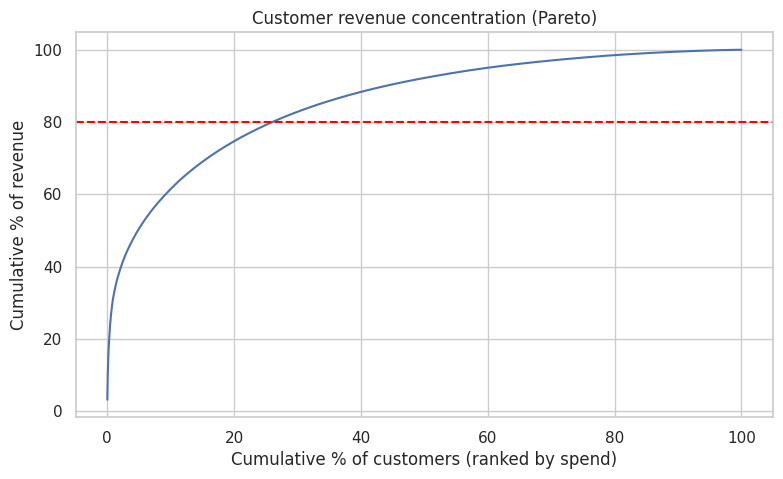

1130 customers (26.0%) generate 80% of revenue.

Top 10 customers by spend (£):
 CustomerID
14646.0    280206.0
18102.0    259657.0
17450.0    194391.0
16446.0    168472.0
14911.0    143711.0
12415.0    124915.0
14156.0    117210.0
17511.0     91062.0
16029.0     80851.0
12346.0     77184.0
Name: TotalRevenue, dtype: float64


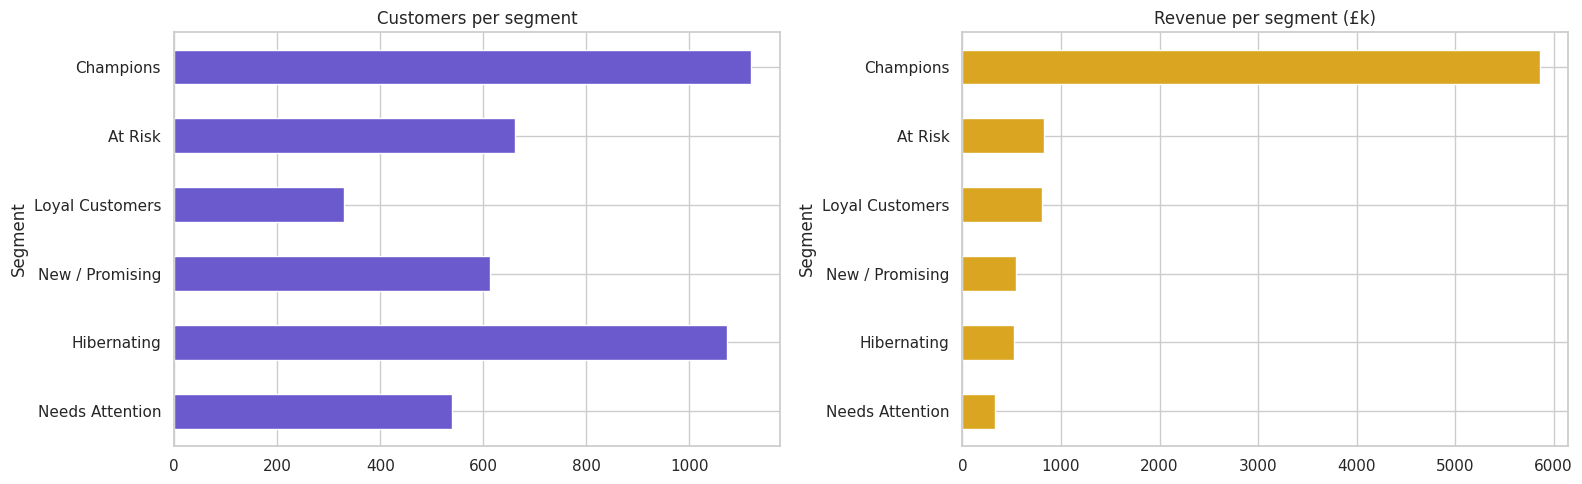

                 Customers      Revenue  RevSharePct
Segment                                             
Champions             1121  5857798.930         65.9
At Risk                661   823912.441          9.3
Loyal Customers        329   807776.941          9.1
New / Promising        614   546620.670          6.2
Hibernating           1074   523803.282          5.9
Needs Attention        539   327296.630          3.7

Segment profiles:
                  Recency  Frequency  Monetary
Segment                                      
At Risk            150.6        3.4    1246.5
Champions           13.0       10.1    5225.5
Hibernating        216.7        1.1     487.7
Loyal Customers     49.0        5.7    2455.2
Needs Attention     52.0        1.6     607.2
New / Promising     16.9        1.8     890.3


In [1]:
# =====================================================================
# ONLINE RETAIL (UCI 352) — FULL EDA  (v3)
# FIX: ucimlrepo stores InvoiceNo & StockCode in ds.data.ids, NOT in
#      ds.data.features. We now stitch ids + features together.
# =====================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (14, 5)

SERVICE_CODES = {
    "POST", "DOT", "DOTCOM POSTAGE", "M", "MANUAL", "BANK CHARGES",
    "C2", "CRUK", "D", "S", "B", "PADS", "AMAZONFEE", "ADJUST",
}
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

# ---------------------------------------------------------------------
# 0. LOAD + COLUMN STANDARDIZATION
# ---------------------------------------------------------------------
COL_ALIASES = {
    "invoice": "InvoiceNo",      "invoiceno": "InvoiceNo",
    "stockcode": "StockCode",    "stock_code": "StockCode",
    "description": "Description",
    "quantity": "Quantity",
    "invoicedate": "InvoiceDate","invoice_date": "InvoiceDate",
    "date": "InvoiceDate",
    "unitprice": "UnitPrice",    "price": "UnitPrice",
    "customerid": "CustomerID",  "customer_id": "CustomerID",
    "customer id": "CustomerID",
    "country": "Country",
}
REQUIRED = {"InvoiceNo", "StockCode", "Quantity", "InvoiceDate",
            "UnitPrice", "Description"}


def load_data(uci_id: int = 352) -> pd.DataFrame:
    """Stitch ucimlrepo's split dataframes back into one 8-column table."""
    ds = fetch_ucirepo(id=uci_id)

    parts = []
    for name in ("ids", "features", "targets"):
        part = getattr(ds.data, name, None)
        if isinstance(part, pd.DataFrame) and part.shape[1] > 0:
            parts.append(part)

    if not parts:
        raise RuntimeError("ucimlrepo returned no data. Try: pip install -U ucimlrepo")

    lens = {len(p) for p in parts}                 # all splits must align row-wise
    if len(lens) != 1:
        raise RuntimeError(f"Row count mismatch between splits: {lens}")

    df = parts[0] if len(parts) == 1 else pd.concat(parts, axis=1)
    print(f"Stitched {len(parts)} split(s) -> shape {df.shape}")   # expect (541909, 8)
    return df


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    key = lambda c: c.lower().replace("-", "_").strip()
    ren = {c: COL_ALIASES[key(c)] for c in df.columns
           if key(c) in COL_ALIASES and c != COL_ALIASES[key(c)]}
    if ren:
        df = df.rename(columns=ren)
        print("Column mapping applied:", ren)

    missing = REQUIRED - set(df.columns)
    if missing:
        raise ValueError(f"Required columns not found: {missing}\n"
                         f"Available: {list(df.columns)}")
    return df


# ---------------------------------------------------------------------
# 1. PROFILE
# ---------------------------------------------------------------------
def profile(df: pd.DataFrame) -> None:
    print(f"Shape: {df.shape}")
    print(f"Duplicates: {df.duplicated().sum():,}")
    print("\nMissing values:")
    miss = df.isna().sum().to_frame("n_missing")
    miss["pct"] = (100 * miss["n_missing"] / len(df)).round(2)
    print(miss[miss.n_missing > 0])
    print("\nNumeric summary:\n",
          df.select_dtypes(include=np.number).describe().T)


# ---------------------------------------------------------------------
# 2. CLEANING & FEATURE ENGINEERING
# ---------------------------------------------------------------------
def parse_invoice_dates(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M",
                "%m/%d/%Y %H:%M", "%m/%d/%Y %H:%M:%S",
                "%d/%m/%Y %H:%M"):
        parsed = pd.to_datetime(s, format=fmt, errors="coerce")
        if parsed.notna().mean() >= 0.9:
            return parsed
    return pd.to_datetime(s, errors="coerce")


def preprocess(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df = df.copy().drop_duplicates()

    for col in ["InvoiceNo", "StockCode", "Country"]:
        df[col] = df[col].astype(str).str.strip()
    df["Description"] = df["Description"].astype(str).str.strip()
    df["InvoiceDate"] = parse_invoice_dates(df["InvoiceDate"])

    bad = df["InvoiceDate"].isna().sum()
    if bad:
        print(f"Dropping {bad} rows with unparseable dates")
        df = df.dropna(subset=["InvoiceDate"])
    print(f"Date range: {df['InvoiceDate'].min()}  ->  {df['InvoiceDate'].max()}")
    # sanity check: should be 2010-12-01 08:26 -> 2011-12-09 09:52

    df["Quantity"]   = pd.to_numeric(df["Quantity"], errors="coerce")
    df["UnitPrice"]  = pd.to_numeric(df["UnitPrice"], errors="coerce")
    df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")
    df["HasCustomerID"] = df["CustomerID"].notna()      # never impute an ID

    code2desc = (df[df["Description"] != "UNKNOWN"]
                 .groupby("StockCode")["Description"]
                 .agg(lambda s: s.mode().iat[0]))
    m = df["Description"] == "UNKNOWN"
    df.loc[m, "Description"] = df.loc[m, "StockCode"].map(code2desc)
    df["Description"] = df["Description"].fillna("UNKNOWN")

    df["IsCancelled"] = df["InvoiceNo"].str.upper().str.startswith("C")
    cancels = df[df["IsCancelled"] | (df["Quantity"] < 0)].copy()
    cancels["ReturnQty"]   = -cancels["Quantity"]
    cancels["RevenueLost"] = cancels["ReturnQty"] * cancels["UnitPrice"]

    sales = df[~df["IsCancelled"] & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
    sales["IsServiceLine"] = sales["StockCode"].str.upper().isin(SERVICE_CODES)

    dt = sales["InvoiceDate"]
    sales["TotalRevenue"] = sales["Quantity"] * sales["UnitPrice"]
    sales["Year"]      = dt.dt.year
    sales["Month"]     = dt.dt.month
    sales["YearMonth"] = dt.dt.to_period("M")
    sales["DayOfWeek"] = dt.dt.dayofweek
    sales["DayName"]   = dt.dt.day_name()
    sales["Hour"]      = dt.dt.hour
    sales["IsWeekend"] = sales["DayOfWeek"] >= 5

    anon = sales.loc[~sales["HasCustomerID"], "TotalRevenue"].sum() \
                / sales["TotalRevenue"].sum()
    print(f"Sales rows: {len(sales):,} | Cancel/return rows: {len(cancels):,} "
          f"| Anonymous revenue share: {anon:.1%}")
    return sales, cancels


def headline_kpis(sales: pd.DataFrame) -> None:
    kpi = {
        "Total revenue (£)": sales["TotalRevenue"].sum(),
        "Invoices": sales["InvoiceNo"].nunique(),
        "Unique products": sales["StockCode"].nunique(),
        "Identified customers": sales.loc[sales["HasCustomerID"], "CustomerID"].nunique(),
        "Avg order value (£)": sales.groupby("InvoiceNo")["TotalRevenue"].sum().mean(),
    }
    for k, v in kpi.items():
        print(f"{k:>22}: {v:,.2f}" if v < 1000 else f"{k:>22}: {v:,.0f}")


# ---------------------------------------------------------------------
# 3. UNIVARIATE ANALYSIS
# ---------------------------------------------------------------------
def plot_distributions(sales: pd.DataFrame) -> None:
    fig, axes = plt.subplots(3, 2, figsize=(14, 10))
    for i, col in enumerate(["Quantity", "UnitPrice", "TotalRevenue"]):
        sns.histplot(sales[col], bins=100, ax=axes[i, 0], color="steelblue")
        axes[i, 0].set_title(f"{col} — raw | skew={sales[col].skew():.1f}")
        p99 = sales[col].quantile(0.99)
        sns.histplot(sales.loc[sales[col] <= p99, col], bins=60,
                     ax=axes[i, 1], color="seagreen")
        axes[i, 1].set_title(f"{col} — clipped at P99 = {p99:,.2f}")
    plt.tight_layout()
    plt.show()


def top_products(sales: pd.DataFrame, n: int = 10):
    prod = (sales[~sales["IsServiceLine"]]
            .groupby("StockCode")
            .agg(Description=("Description", "first"),
                 UnitsSold=("Quantity", "sum"),
                 Revenue=("TotalRevenue", "sum"),
                 Orders=("InvoiceNo", "nunique")))
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for ax, col, title in [(axes[0], "UnitsSold", f"Top {n} by UNITS"),
                           (axes[1], "Revenue",   f"Top {n} by REVENUE (£)")]:
        top = prod.nlargest(n, col).iloc[::-1]
        ax.barh(top["Description"].astype(str).str[:38], top[col], color="teal")
        ax.set_title(title)
        ax.tick_params(axis="y", labelsize=9)
    plt.tight_layout()
    plt.show()
    return prod.nlargest(n, "UnitsSold"), prod.nlargest(n, "Revenue")


def country_distribution(sales: pd.DataFrame) -> pd.DataFrame:
    ctry = (sales.groupby("Country")
                 .agg(Revenue=("TotalRevenue", "sum"),
                      Orders=("InvoiceNo", "nunique"),
                      Customers=("CustomerID", "nunique"))
                 .sort_values("Revenue", ascending=False))
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    (ctry["Revenue"] / 1e3).head(10).plot.barh(ax=axes[0], color="slateblue")
    axes[0].set(title="Top 10 countries by revenue (£k)")
    axes[0].invert_yaxis()
    no_uk = ctry.drop(index="United Kingdom", errors="ignore")
    (no_uk["Revenue"] / 1e3).head(10).plot.barh(ax=axes[1], color="coral")
    axes[1].set(title="Top 10 countries EXCL. UK (£k)")
    axes[1].invert_yaxis()
    plt.tight_layout()
    plt.show()
    return ctry


# ---------------------------------------------------------------------
# 4. TIME-SERIES & SEASONALITY
# ---------------------------------------------------------------------
def monthly_trend(sales: pd.DataFrame) -> pd.DataFrame:
    monthly = (sales.groupby("YearMonth")
                    .agg(Revenue=("TotalRevenue", "sum"),
                         Orders=("InvoiceNo", "nunique")))
    fig, ax1 = plt.subplots(figsize=(14, 5))
    ax1.plot(monthly.index.astype(str), monthly["Revenue"] / 1e3,
             marker="o", color="navy", label="Revenue (£k)")
    ax2 = ax1.twinx()
    ax2.plot(monthly.index.astype(str), monthly["Orders"], ls="--",
             color="darkorange", alpha=0.7, label="Orders")
    ax1.set(title="Monthly revenue & order volume", ylabel="Revenue (£k)")
    ax2.set_ylabel("Orders")
    ax1.tick_params(axis="x", rotation=45)
    n = len(monthly)
    ax1.annotate("Partial month\n(ends 09-Dec-2011)",
                 xy=(n - 1, monthly["Revenue"].iloc[-1] / 1e3),
                 xytext=(n - 4, monthly["Revenue"].max() / 1e3 * 0.55),
                 arrowprops=dict(arrowstyle="->", color="crimson"),
                 color="crimson", fontsize=9)
    fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.9))
    plt.tight_layout()
    plt.show()
    return monthly


def weekday_hour_patterns(sales: pd.DataFrame) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    (sales.groupby("DayName")["TotalRevenue"].sum().reindex(DOW_ORDER) / 1e3) \
        .plot.bar(ax=axes[0], color="seagreen")
    axes[0].set(title="Revenue by day of week (£k)", xlabel="")
    (sales.groupby("Hour")["TotalRevenue"].sum() / 1e3) \
        .plot.bar(ax=axes[1], color="indianred")
    axes[1].set(title="Revenue by hour (£k)", xlabel="Hour of day")
    plt.tight_layout()
    plt.show()

    pivot = (sales.pivot_table(index="DayName", columns="Hour",
                               values="InvoiceNo", aggfunc="nunique")
                  .reindex(index=DOW_ORDER, columns=range(6, 21)))
    plt.figure(figsize=(14, 4))
    sns.heatmap(pivot, cmap="YlGnBu", linewidths=0.3,
                cbar_kws={"label": "Unique invoices"})
    plt.title("Order density — day × hour (Saturday is empty in this dataset)")
    plt.show()


# ---------------------------------------------------------------------
# 5. CUSTOMER BEHAVIOR & RFM
# ---------------------------------------------------------------------
def purchase_frequency(sales: pd.DataFrame) -> pd.Series:
    cust = sales[sales["HasCustomerID"]]
    freq = cust.groupby("CustomerID")["InvoiceNo"].nunique().rename("Frequency")
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    sns.histplot(freq.clip(upper=15), discrete=True, ax=axes[0], color="teal")
    axes[0].set(title="Invoices per customer (15+ clipped)", xlabel="Distinct invoices")
    repeat = (freq > 1).mean() * 100
    axes[1].pie([repeat, 100 - repeat],
                labels=[f"Repeat\n{repeat:.1f}%", f"One-time\n{100-repeat:.1f}%"],
                colors=["seagreen", "lightgray"], autopct="%1.1f%%")
    axes[1].set_title("Repeat-purchase rate")
    plt.tight_layout()
    plt.show()
    return freq


def pareto_customers(sales: pd.DataFrame) -> pd.Series:
    rev = (sales[sales["HasCustomerID"]]
           .groupby("CustomerID")["TotalRevenue"].sum()
           .sort_values(ascending=False))
    cum_share = rev.cumsum() / rev.sum()
    plt.figure(figsize=(9, 5))
    plt.plot(np.arange(1, len(rev) + 1) / len(rev) * 100, cum_share * 100)
    plt.axhline(80, ls="--", color="red")
    plt.xlabel("Cumulative % of customers (ranked by spend)")
    plt.ylabel("Cumulative % of revenue")
    plt.title("Customer revenue concentration (Pareto)")
    plt.show()
    n80 = int((cum_share < 0.80).sum()) + 1
    print(f"{n80} customers ({100 * n80 / len(rev):.1f}%) generate 80% of revenue.")
    print("\nTop 10 customers by spend (£):\n", rev.head(10).round(0))
    return rev


def build_rfm(sales: pd.DataFrame, snapshot: pd.Timestamp | None = None) -> pd.DataFrame:
    cust = sales[sales["HasCustomerID"]]
    snapshot = snapshot or (sales["InvoiceDate"].max() + pd.Timedelta(days=1))
    rfm = (cust.groupby("CustomerID")
               .agg(Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
                    Frequency=("InvoiceNo", "nunique"),
                    Monetary=("TotalRevenue", "sum")))
    rfm.index = rfm.index.astype(int)
    rfm["R"] = pd.qcut(rfm["Recency"].rank(method="first"), 5,
                       labels=[5, 4, 3, 2, 1]).astype(int)
    rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5,
                       labels=[1, 2, 3, 4, 5]).astype(int)
    rfm["M"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5,
                       labels=[1, 2, 3, 4, 5]).astype(int)
    rfm["RFM"] = (rfm["R"].astype(str) + rfm["F"].astype(str)
                  + rfm["M"].astype(str))
    return rfm


def label_segments(rfm: pd.DataFrame) -> pd.DataFrame:
    rfm = rfm.copy()
    conds = [
        (rfm["R"] >= 4) & (rfm["F"] >= 4),
        (rfm["R"] >= 3) & (rfm["F"] >= 4),
        (rfm["R"] >= 4) & (rfm["F"] <= 3),
        (rfm["R"] == 3),
        (rfm["R"] <= 2) & (rfm["F"] >= 3),
        (rfm["R"] <= 2) & (rfm["F"] <= 2),
    ]
    labels = ["Champions", "Loyal Customers", "New / Promising",
              "Needs Attention", "At Risk", "Hibernating"]
    rfm["Segment"] = np.select(conds, labels, default="Others")
    return rfm


def plot_segments(rfm: pd.DataFrame) -> None:
    seg = (rfm.groupby("Segment")
              .agg(Customers=("Monetary", "size"), Revenue=("Monetary", "sum"))
              .sort_values("Revenue", ascending=False))
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    seg["Customers"].plot.barh(ax=axes[0], color="slateblue",
                               title="Customers per segment")
    (seg["Revenue"] / 1e3).plot.barh(ax=axes[1], color="goldenrod",
                                     title="Revenue per segment (£k)")
    for ax in axes:
        ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(seg.assign(RevSharePct=(100 * seg["Revenue"] / seg["Revenue"].sum()).round(1)))
    print("\nSegment profiles:\n",
          rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
             .mean().round(1))


# ---------------------------------------------------------------------
# 6. RUN EVERYTHING
# ---------------------------------------------------------------------
def main() -> None:
    raw = standardize_columns(load_data(352))
    profile(raw)

    sales, cancels = preprocess(raw)
    headline_kpis(sales)

    plot_distributions(sales)
    top_products(sales)
    country_distribution(sales)

    monthly_trend(sales)
    weekday_hour_patterns(sales)

    print("\nCancellation share of raw rows: {:.2%}".format(len(cancels) / len(raw)))
    print("Top 5 returned products (units):\n",
          cancels.groupby("Description")["ReturnQty"].sum()
                 .sort_values(ascending=False).head(5))

    purchase_frequency(sales)
    pareto_customers(sales)
    rfm = label_segments(build_rfm(sales))
    plot_segments(rfm)


main()

# insights

# Exploratory Data Analysis & RFM Diagnostics Summary

## 1. Dataset Overview & Data Quality
* **Total Transactions:** 524,878 sales rows | 10,587 return/cancellation rows.
* **Total Revenue:** £10,642,111 across 19,960 unique invoices and 3,922 unique products.
* **Identified Customers:** 4,338 unique registered users.
* **Anonymous Guest Checkouts:** ~25% of total rows missing `CustomerID`, representing **16.5% of overall revenue**.
* **Data Skewness:** Extreme positive skew in `Quantity` (469.5) and `TotalRevenue` (504.2) caused by B2B/wholesale accounts.

## 2. Metric Distributions & Anomalies
* **Quantity (Clipped at P99 = 100):** Prominent spikes occur at multiples of 6, 12, and 24 due to wholesale case packaging and volume discount tiers. Extreme outliers reach up to 80,000+ units.
* **UnitPrice (Clipped at P99 = £16.98):** Concentrated heavily between £1.00 and £5.00, reflecting low-cost gift items and novelties.
* **Total Line Revenue (Clipped at P99 = £183.60):** Massively decaying distribution; the vast majority of individual line items fall under £30.00.

## 3. Product & Geographic Insights
* **Top Products by Volume:** *Paper Craft, Little Birdie* (~80k units) and *Medium Ceramic Top Storage Jar* (~75k units).
* **Top Products by Revenue:** *Regency Cakestand 3 Tier* (>£175k revenue) leads high-margin items.
* **Geographic Distribution:**
  * **Domestic:** UK dominates the business (~£9M revenue).
  * **International:** Netherlands, EIRE (Ireland), Germany, and France lead cross-border sales.

## 4. Temporal & Operational Patterns
* **Seasonality:** Strong Q4 demand ramp-up starting in September, peaking heavily in November (~£1.5M/month) for holiday inventory stocking.
* **Weekly Schedule:** **Zero transactions recorded on Saturdays** (warehouse/system downtime).
* **Peak Shopping Hours:** Transactions peak between **10:00 AM and 12:00 PM** on Tuesdays and Thursdays.

## 5. Retention & RFM Segmentation Findings
* **Repeat Rate:** **65.6%** of identified customers are repeat buyers; 34.4% are one-time buyers.
* **Pareto Principle (80/26 Rule):** **26% of customers (1,130 users) generate 80% of total revenue**. The top individual customer spent £280,206.

### Segment Performance Summary
1. **Champions (1,121 users | 65.9% Revenue Share):**
   * *Profile:* Recency = 13 days | Frequency = 10.1 orders | Spend = £5,225.50
   * *Action:* Core VIP group driving two-thirds of business revenue. Priority for loyalty retention.
2. **At Risk (661 users | 9.3% Revenue Share):**
   * *Profile:* Recency = 150.6 days | Frequency = 3.4 orders | Spend = £1,246.50
   * *Action:* Formerly high-value buyers inactive for ~5 months. Top priority for win-back campaigns.
3. **Loyal Customers (329 users | 9.1% Revenue Share):**
   * *Profile:* Recency = 49 days | Frequency = 5.7 orders | Spend = £2,455.20
   * *Action:* Steady repeat buyers; candidates for upsell and subscription programs.
4. **New / Promising (614 users | 6.2% Revenue Share):**
   * *Profile:* Recency = 16.9 days | Frequency = 1.8 orders | Spend = £890.30
   * *Action:* Recent shoppers requiring onboarding sequences to encourage a second purchase.
5. **Hibernating (1,074 users | 5.9% Revenue Share):**
   * *Profile:* Recency = 216.7 days | Frequency = 1.1 orders | Spend = £487.70
   * *Action:* Disengaged low-value buyers. Low priority for marketing spend.
6. **Needs Attention (539 users | 3.7% Revenue Share):**
   * *Profile:* Recency = 52 days | Frequency = 1.6 orders | Spend = £607.20
   * *Action:* Moderate recency with low order frequency; slipping toward churn.

# streamlit app

In [ ]:
%%writefile app.py
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from ucimlrepo import fetch_ucirepo

st.set_page_config(page_title="Online Retail EDA", page_icon="🛒", layout="wide")
sns.set_theme(style="whitegrid", palette="deep")

SERVICE_CODES = {
    "POST", "DOT", "DOTCOM POSTAGE", "M", "MANUAL", "BANK CHARGES",
    "C2", "CRUK", "D", "S", "B", "PADS", "AMAZONFEE", "ADJUST",
}
DOW_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

COL_ALIASES = {
    "invoice": "InvoiceNo",      "invoiceno": "InvoiceNo",
    "stockcode": "StockCode",    "stock_code": "StockCode",
    "description": "Description",
    "quantity": "Quantity",
    "invoicedate": "InvoiceDate","invoice_date": "InvoiceDate",
    "date": "InvoiceDate",
    "unitprice": "UnitPrice",    "price": "UnitPrice",
    "customerid": "CustomerID",  "customer_id": "CustomerID",
    "customer id": "CustomerID",
    "country": "Country",
}
REQUIRED = {"InvoiceNo", "StockCode", "Quantity", "InvoiceDate",
            "UnitPrice", "Description"}


# ---------------------------------------------------------------------
# DATA LAYER (cached — heavy work runs only once)
# ---------------------------------------------------------------------
@st.cache_data(show_spinner="⬇️ Fetching dataset from UCI (first run ≈ 40 s, then cached)…")
def load_raw() -> pd.DataFrame:
    """ucimlrepo splits ids (InvoiceNo, StockCode) from features — stitch back."""
    ds = fetch_ucirepo(id=352)
    parts = []
    for name in ("ids", "features", "targets"):
        part = getattr(ds.data, name, None)
        if isinstance(part, pd.DataFrame) and part.shape[1] > 0:
            parts.append(part)
    if not parts:
        raise RuntimeError("ucimlrepo returned no data — try: pip install -U ucimlrepo")
    return parts[0] if len(parts) == 1 else pd.concat(parts, axis=1)


def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    key = lambda c: c.lower().replace("-", "_").strip()
    ren = {c: COL_ALIASES[key(c)] for c in df.columns
           if key(c) in COL_ALIASES and c != COL_ALIASES[key(c)]}
    if ren:
        df = df.rename(columns=ren)
    missing = REQUIRED - set(df.columns)
    if missing:
        raise ValueError(f"Required columns not found: {missing}\n"
                         f"Available: {list(df.columns)}")
    return df


def parse_invoice_dates(s: pd.Series) -> pd.Series:
    s = s.astype(str).str.strip()
    for fmt in ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M",
                "%m/%d/%Y %H:%M", "%m/%d/%Y %H:%M:%S", "%d/%m/%Y %H:%M"):
        parsed = pd.to_datetime(s, format=fmt, errors="coerce")
        if parsed.notna().mean() >= 0.9:
            return parsed
    return pd.to_datetime(s, errors="coerce")


@st.cache_data(show_spinner="🧹 Cleaning & feature engineering…")
def preprocess(raw: pd.DataFrame):
    df = raw.copy()
    info = {"raw_rows": len(df), "dupes": int(df.duplicated().sum())}
    df = df.drop_duplicates()

    for col in ["InvoiceNo", "StockCode", "Country"]:
        df[col] = df[col].astype(str).str.strip()
    df["Description"] = df["Description"].astype(str).str.strip()
    df["InvoiceDate"] = parse_invoice_dates(df["InvoiceDate"])
    n_bad_dates = int(df["InvoiceDate"].isna().sum())
    df = df.dropna(subset=["InvoiceDate"])

    df["Quantity"]   = pd.to_numeric(df["Quantity"], errors="coerce")
    df["UnitPrice"]  = pd.to_numeric(df["UnitPrice"], errors="coerce")
    df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")
    df["HasCustomerID"] = df["CustomerID"].notna()

    code2desc = (df[df["Description"] != "UNKNOWN"]
                 .groupby("StockCode")["Description"]
                 .agg(lambda s: s.mode().iat[0]))
    m = df["Description"] == "UNKNOWN"
    df.loc[m, "Description"] = df.loc[m, "StockCode"].map(code2desc)
    df["Description"] = df["Description"].fillna("UNKNOWN")

    df["IsCancelled"] = df["InvoiceNo"].str.upper().str.startswith("C")
    cancels = df[df["IsCancelled"] | (df["Quantity"] < 0)].copy()
    cancels["ReturnQty"]   = -cancels["Quantity"]
    cancels["RevenueLost"] = cancels["ReturnQty"] * cancels["UnitPrice"].fillna(0)

    sales = df[~df["IsCancelled"] & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()
    sales["IsServiceLine"] = sales["StockCode"].str.upper().isin(SERVICE_CODES)

    dt = sales["InvoiceDate"]
    sales["TotalRevenue"] = sales["Quantity"] * sales["UnitPrice"]
    sales["YearMonth"] = dt.dt.to_period("M")
    sales["DayOfWeek"] = dt.dt.dayofweek
    sales["DayName"]   = dt.dt.day_name()
    sales["Hour"]      = dt.dt.hour

    info.update({
        "bad_dates": n_bad_dates,
        "date_min": df["InvoiceDate"].min(),
        "date_max": df["InvoiceDate"].max(),
        "n_sales": len(sales),
        "n_cancels": len(cancels),
        "anon_share": sales.loc[~sales["HasCustomerID"], "TotalRevenue"].sum()
                       / sales["TotalRevenue"].sum(),
    })
    return sales, cancels, info


# ---------------------------------------------------------------------
# PLOT BUILDERS (return figs — Streamlit renders them)
# ---------------------------------------------------------------------
def show(fig):
    st.pyplot(fig, bbox_inches="tight")
    plt.close(fig)


def fig_distributions(sales: pd.DataFrame):
    fig, axes = plt.subplots(3, 2, figsize=(13, 9))
    for i, col in enumerate(["Quantity", "UnitPrice", "TotalRevenue"]):
        sns.histplot(sales[col], bins=100, ax=axes[i, 0], color="steelblue")
        axes[i, 0].set_title(f"{col} — raw | skew={sales[col].skew():.1f}")
        p99 = sales[col].quantile(0.99)
        sns.histplot(sales.loc[sales[col] <= p99, col], bins=60,
                     ax=axes[i, 1], color="seagreen")
        axes[i, 1].set_title(f"{col} — clipped at P99 = {p99:,.2f}")
    fig.tight_layout()
    return fig


def fig_top_products(sales: pd.DataFrame, n: int = 10):
    prod = (sales[~sales["IsServiceLine"]]
            .groupby("StockCode")
            .agg(Description=("Description", "first"),
                 UnitsSold=("Quantity", "sum"),
                 Revenue=("TotalRevenue", "sum")))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    for ax, col, title in [(axes[0], "UnitsSold", f"Top {n} by UNITS"),
                           (axes[1], "Revenue",   f"Top {n} by REVENUE (£)")]:
        top = prod.nlargest(n, col).iloc[::-1]
        ax.barh(top["Description"].astype(str).str[:38], top[col], color="teal")
        ax.set_title(title)
        ax.tick_params(axis="y", labelsize=9)
    fig.tight_layout()
    return fig


def fig_countries(sales: pd.DataFrame):
    ctry = (sales.groupby("Country")["TotalRevenue"].sum()
                 .sort_values(ascending=False))
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    (ctry / 1e3).head(10).iloc[::-1].plot.barh(ax=axes[0], color="slateblue")
    axes[0].set(title="Top 10 countries by revenue (£k)")
    no_uk = ctry.drop(index="United Kingdom", errors="ignore")
    (no_uk / 1e3).head(10).iloc[::-1].plot.barh(ax=axes[1], color="coral")
    axes[1].set(title="Top 10 EXCL. UK (£k)")
    fig.tight_layout()
    return fig, ctry


def fig_monthly(sales: pd.DataFrame):
    monthly = (sales.groupby("YearMonth")
                    .agg(Revenue=("TotalRevenue", "sum"),
                         Orders=("InvoiceNo", "nunique")))
    fig, ax1 = plt.subplots(figsize=(13, 4.5))
    ax1.plot(monthly.index.astype(str), monthly["Revenue"] / 1e3,
             marker="o", color="navy")
    ax2 = ax1.twinx()
    ax2.plot(monthly.index.astype(str), monthly["Orders"], ls="--",
             color="darkorange", alpha=0.7)
    ax1.set(title="Monthly revenue (£k, navy) & orders (dashed orange)",
            ylabel="Revenue (£k)")
    ax1.tick_params(axis="x", rotation=45)
    if str(monthly.index[-1]) == "2011-12":     # partial final month
        ax1.annotate("Partial month\n(ends 09-Dec-2011)",
                     xy=(len(monthly) - 1, monthly["Revenue"].iloc[-1] / 1e3),
                     xytext=(len(monthly) - 4, monthly["Revenue"].max() / 1e3 * 0.6),
                     arrowprops=dict(arrowstyle="->", color="crimson"),
                     color="crimson", fontsize=9)
    fig.tight_layout()
    return fig, monthly


def fig_weekday_hour(sales: pd.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    (sales.groupby("DayName")["TotalRevenue"].sum().reindex(DOW_ORDER) / 1e3) \
        .plot.bar(ax=axes[0], color="seagreen")
    axes[0].set(title="Revenue by day of week (£k)")
    (sales.groupby("Hour")["TotalRevenue"].sum() / 1e3) \
        .plot.bar(ax=axes[1], color="indianred")
    axes[1].set(title="Revenue by hour (£k)")
    fig.tight_layout()

    pivot = (sales.pivot_table(index="DayName", columns="Hour",
                               values="InvoiceNo", aggfunc="nunique")
                  .reindex(index=DOW_ORDER, columns=range(6, 21)))
    fig2, ax = plt.subplots(figsize=(13, 3.5))
    sns.heatmap(pivot, cmap="YlGnBu", linewidths=0.3, ax=ax,
                cbar_kws={"label": "Unique invoices"})
    ax.set_title("Order density — day × hour (Saturday is empty in the raw data)")
    fig2.tight_layout()
    return fig, fig2


def fig_frequency(sales: pd.DataFrame):
    freq = (sales[sales["HasCustomerID"]]
            .groupby("CustomerID")["InvoiceNo"].nunique())
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    sns.histplot(freq.clip(upper=15), discrete=True, ax=axes[0], color="teal")
    axes[0].set(title="Invoices per customer (15+ clipped)")
    repeat = (freq > 1).mean() * 100
    axes[1].pie([repeat, 100 - repeat],
                labels=[f"Repeat\n{repeat:.1f}%", f"One-time\n{100-repeat:.1f}%"],
                colors=["seagreen", "lightgray"], autopct="%1.1f%%")
    axes[1].set_title("Repeat-purchase rate")
    fig.tight_layout()
    return fig


def fig_pareto(sales: pd.DataFrame):
    rev = (sales[sales["HasCustomerID"]]
           .groupby("CustomerID")["TotalRevenue"].sum()
           .sort_values(ascending=False))
    cum = rev.cumsum() / rev.sum()
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(np.arange(1, len(rev) + 1) / len(rev) * 100, cum * 100)
    ax.axhline(80, ls="--", color="red")
    ax.set(xlabel="Cumulative % of customers (ranked by spend)",
           ylabel="Cumulative % of revenue",
           title="Customer revenue concentration (Pareto)")
    fig.tight_layout()
    n80 = int((cum < 0.80).sum()) + 1
    return fig, f"**{n80} customers ({100*n80/len(rev):.1f}%) generate 80% of revenue.**"


def build_rfm(sales: pd.DataFrame) -> pd.DataFrame:
    cust = sales[sales["HasCustomerID"]]
    snapshot = sales["InvoiceDate"].max() + pd.Timedelta(days=1)
    rfm = (cust.groupby("CustomerID")
               .agg(Recency=("InvoiceDate", lambda s: (snapshot - s.max()).days),
                    Frequency=("InvoiceNo", "nunique"),
                    Monetary=("TotalRevenue", "sum")))
    rfm.index = rfm.index.astype(int)
    rfm["R"] = pd.qcut(rfm["Recency"].rank(method="first"), 5,
                       labels=[5, 4, 3, 2, 1]).astype(int)
    rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5,
                       labels=[1, 2, 3, 4, 5]).astype(int)
    rfm["M"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5,
                       labels=[1, 2, 3, 4, 5]).astype(int)
    return rfm


def label_segments(rfm: pd.DataFrame) -> pd.DataFrame:
    rfm = rfm.copy()
    conds = [
        (rfm["R"] >= 4) & (rfm["F"] >= 4),
        (rfm["R"] >= 3) & (rfm["F"] >= 4),
        (rfm["R"] >= 4) & (rfm["F"] <= 3),
        (rfm["R"] == 3),
        (rfm["R"] <= 2) & (rfm["F"] >= 3),
        (rfm["R"] <= 2) & (rfm["F"] <= 2),
    ]
    labels = ["Champions", "Loyal Customers", "New / Promising",
              "Needs Attention", "At Risk", "Hibernating"]
    rfm["Segment"] = np.select(conds, labels, default="Others")
    return rfm


def fig_segments(rfm: pd.DataFrame):
    seg = (rfm.groupby("Segment")
              .agg(Customers=("Monetary", "size"), Revenue=("Monetary", "sum"))
              .sort_values("Revenue", ascending=False))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    seg["Customers"].plot.barh(ax=axes[0], color="slateblue")
    axes[0].set_title("Customers per segment")
    (seg["Revenue"] / 1e3).plot.barh(ax=axes[1], color="goldenrod")
    axes[1].set_title("Revenue per segment (£k)")
    for ax in axes:
        ax.invert_yaxis()
    fig.tight_layout()
    return fig, seg


def fig_returns(cancels: pd.DataFrame):
    top = (cancels.groupby("Description")["ReturnQty"].sum()
                  .sort_values(ascending=False).head(10).iloc[::-1])
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.barh(top.index.astype(str).str[:38], top.values, color="tomato")
    ax.set_title("Top 10 returned products (units)")
    ax.tick_params(axis="y", labelsize=9)
    fig.tight_layout()
    return fig


# ---------------------------------------------------------------------
# APP LAYOUT
# ---------------------------------------------------------------------
st.title("🛒 Online Retail — Exploratory Data Analysis")
st.caption("UCI Dataset 352 · Dec 2010 – Dec 2011 · all figures in £")

# --- load (cached) ---
try:
    raw = standardize_columns(load_raw())
    sales, cancels, info = preprocess(raw)
except (ValueError, RuntimeError) as e:
    st.error(f"Data loading failed: {e}")
    st.stop()

with st.expander("🧹 Data cleaning log"):
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("Raw rows", f"{info['raw_rows']:,}")
    c1.metric("Exact duplicates dropped", f"{info['dupes']:,}")
    c2.metric("Sales rows", f"{info['n_sales']:,}")
    c2.metric("Cancel/return rows", f"{info['n_cancels']:,}")
    c3.metric("Date range", f"{info['date_min']:%d %b %Y}",
              f"→ {info['date_max']:%d %b %Y}")
    c3.metric("Unparseable dates dropped", info["bad_dates"])
    c4.metric("Anonymous revenue share", f"{info['anon_share']:.1%}",
              "no CustomerID")

# --- sidebar filters ---
st.sidebar.header("🔎 Filters")
d_min, d_max = sales["InvoiceDate"].min().date(), sales["InvoiceDate"].max().date()
picked = st.sidebar.date_input("Date range", (d_min, d_max),
                               min_value=d_min, max_value=d_max)
d0, d1 = (picked if isinstance(picked, tuple) and len(picked) == 2
          else (picked, picked))

countries = st.sidebar.multiselect(
    "Countries", sorted(sales["Country"].unique()),
    default=sorted(sales["Country"].unique()))

if st.sidebar.button("🔄 Clear cache & refetch"):
    st.cache_data.clear()

# --- apply filters ---
mask = sales["InvoiceDate"].dt.date.between(d0, d1) & sales["Country"].isin(countries)
fsales = sales[mask]
if fsales.empty:
    st.warning("No sales match this filter combination — widen the date range or countries.")
    st.stop()

fcan_mask = cancels["InvoiceDate"].dt.date.between(d0, d1) & cancels["Country"].isin(countries)
fcancels = cancels[fcan_mask]

# --- KPI row ---
st.subheader("Key metrics (filtered)")
rev = fsales["TotalRevenue"].sum()
k1, k2, k3, k4, k5 = st.columns(5)
k1.metric("Total revenue", f"£{rev:,.0f}",
          f"{100 * rev / sales['TotalRevenue'].sum():.0f}% of dataset")
k2.metric("Invoices", f"{fsales['InvoiceNo'].nunique():,}")
k3.metric("Unique products", f"{fsales['StockCode'].nunique():,}")
k4.metric("Identified customers",
          f"{fsales.loc[fsales['HasCustomerID'], 'CustomerID'].nunique():,}")
k5.metric("Avg order value",
          f"£{fsales.groupby('InvoiceNo')['TotalRevenue'].sum().mean():,.2f}")

# --- tabs ---
tab1, tab2, tab3, tab4, tab5 = st.tabs(
    ["📉 Distributions", "🏆 Products & Countries",
     "📅 Time Trends", "👥 Customers & RFM", "↩️ Cancellations"])

with tab1:
    st.caption("Numeric fields are extremely right-skewed — raw plots are unreadable, "
               "so each variable is also shown clipped at its 99th percentile.")
    show(fig_distributions(fsales))

with tab2:
    n = st.selectbox("How many top products?", [5, 10, 15, 20], index=1)
    show(fig_top_products(fsales, n))
    st.divider()
    fig_c, ctry = fig_countries(fsales)
    show(fig_c)
    st.dataframe(ctry.to_frame("Revenue (£)").round(0), use_container_width=True)
    st.download_button("⬇️ Download country summary (CSV)",
                       ctry.round(0).to_csv().encode(), "country_revenue.csv",
                       "text/csv")

with tab3:
    fig_m, monthly = fig_monthly(fsales)
    show(fig_m)
    show_tab = st.toggle("Show monthly table", value=False)
    if show_tab:
        st.dataframe(monthly.round(0), use_container_width=True)
    fig_w, fig_h = fig_weekday_hour(fsales)
    show(fig_w)
    show(fig_h)

with tab4:
    n_cust = fsales.loc[fsales["HasCustomerID"], "CustomerID"].nunique()
    if n_cust < 5:
        st.info("Fewer than 5 identified customers in this filter — RFM needs more data.")
    else:
        show(fig_frequency(fsales))
        fig_p, pareto_txt = fig_pareto(fsales)
        cA, cB = st.columns([2, 1])
        with cA:
            show(fig_p)
        with cB:
            st.markdown(pareto_txt)

        st.divider()
        st.subheader("RFM segmentation")
        st.caption(f"Snapshot = last purchase in selection + 1 day "
                   f"({fsales['InvoiceDate'].max():%d %b %Y}). "
                   "R/F/M scored 1–5 by quintile; R: 5 = most recent.")
        rfm = label_segments(build_rfm(fsales))
        fig_s, seg = fig_segments(rfm)
        show(fig_s)
        st.dataframe(seg.assign(RevSharePct=(
            100 * seg["Revenue"] / seg["Revenue"].sum()).round(1)),
            use_container_width=True)
        st.dataframe(rfm.head(500), use_container_width=True)
        st.download_button("⬇️ Download full RFM segments (CSV)",
                           rfm.to_csv().encode(), "rfm_segments.csv", "text/csv")

with tab5:
    st.caption("Cancellations (InvoiceNo starting with 'C' / negative quantities) "
               "are excluded from all sales metrics above and analysed here separately.")
    cA, cB = st.columns(2)
    cA.metric("Cancel/return rows", f"{len(fcancels):,}")
    cB.metric("Revenue lost (£)", f"{fcancels['RevenueLost'].sum():,.0f}")
    if not fcancels.empty:
        show(fig_returns(fcancels))
    else:
        st.info("No cancellations in this filter selection.")

Writing app.py


In [3]:
!streamlit run app.py

2026-08-28 12:07:19.397 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://192.168.1.10:8501

  Help agents write better Streamlit apps?
  Install the official Streamlit skills by running streamlit skills in your terminal.

2026-08-28 12:08:12.617 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-28 12:08:15.129 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.
2026-08-28 12:08:15.130 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For

# preprocessing

In [21]:
%%writefile retail_preprocessing.py
# ====================================================================
# preprocessing.py — Online Retail (UCI 352) preprocessing pipeline
# Usage (notebook):   from preprocessing import run_pipeline
#                     sales, cancels, log = run_pipeline()
# Usage (Streamlit):  wrap run_pipeline() in @st.cache_data
# =====================================================================
from __future__ import annotations

import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

# ---------------------------------------------------------------------
# Constants
# ---------------------------------------------------------------------
SERVICE_CODES = {  # non-product lines: excluded from product rankings only
    "POST", "DOT", "DOTCOM POSTAGE", "M", "MANUAL", "BANK CHARGES",
    "C2", "CRUK", "D", "S", "B", "PADS", "AMAZONFEE", "ADJUST",
}
COL_ALIASES = {  # any known lowercase variant -> canonical name
    "invoice": "InvoiceNo",      "invoiceno": "InvoiceNo",
    "stockcode": "StockCode",    "stock_code": "StockCode",
    "description": "Description",
    "quantity": "Quantity",
    "invoicedate": "InvoiceDate", "invoice_date": "InvoiceDate",
    "date": "InvoiceDate",
    "unitprice": "UnitPrice",    "price": "UnitPrice",
    "customerid": "CustomerID",  "customer_id": "CustomerID",
    "customer id": "CustomerID",
    "country": "Country",
}
REQUIRED = {"InvoiceNo", "StockCode", "Quantity", "InvoiceDate",
            "UnitPrice", "Description"}

# Ground truth for validation (dataset v1). tol = allowed relative drift.
EXPECTED = {
    "raw_rows":              (541_909, 0.00),
    "duplicates_dropped":    (5_268,   0.10),
    "sales_rows":            (524_878, 0.01),
    "cancels_rows":          (10_587,  0.01),
    "anon_revenue_share":    (0.165,   0.10),
}
DATE_FORMATS = ("%Y-%m-%d %H:%M:%S", "%Y-%m-%d %H:%M",
                "%m/%d/%Y %H:%M",   "%m/%d/%Y %H:%M:%S",
                "%d/%m/%Y %H:%M")


# ---------------------------------------------------------------------
# 1. LOAD — ucimlrepo splits ids from features; stitch them back
# ---------------------------------------------------------------------
def load_data(uci_id: int = 352) -> pd.DataFrame:
    """Fetch UCI 352 and re-join the ids/features/targets splits row-wise."""
    ds = fetch_ucirepo(id=uci_id)

    parts = []
    for name in ("ids", "features", "targets"):          # targets is empty here
        part = getattr(ds.data, name, None)
        if isinstance(part, pd.DataFrame) and part.shape[1] > 0:
            parts.append(part)
    if not parts:
        raise RuntimeError("ucimlrepo returned no data — try: pip install -U ucimlrepo")

    lens = {len(p) for p in parts}                       # splits must align row-wise
    if len(lens) != 1:
        raise RuntimeError(f"Row-count mismatch between ucimlrepo splits: {lens}")

    df = parts[0] if len(parts) == 1 else pd.concat(parts, axis=1)
    return df


# ---------------------------------------------------------------------
# 2. STANDARDIZE — alias-map column names; fail loudly if incomplete
# ---------------------------------------------------------------------
def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rename known column variants to canonical names; validate required set."""
    df = df.copy()
    df.columns = [str(c).strip() for c in df.columns]
    key = lambda c: c.lower().replace("-", "_").strip()
    ren = {c: COL_ALIASES[key(c)] for c in df.columns
           if key(c) in COL_ALIASES and c != COL_ALIASES[key(c)]}
    df = df.rename(columns=ren)

    missing = REQUIRED - set(df.columns)
    if missing:                                          # never fail silently
        raise ValueError(f"Required columns not found: {missing}\n"
                         f"Available: {list(df.columns)}")
    return df


# ---------------------------------------------------------------------
# 3. DATE PARSING — text -> datetime, explicit formats, coerced failures
# ---------------------------------------------------------------------
def parse_invoice_dates(s: pd.Series) -> pd.Series:
    """Parse InvoiceDate text (e.g. '12/1/2010 8:26'); NaT on failure."""
    if pd.api.types.is_datetime64_any_dtype(s):          # already parsed
        return s
    s = s.astype(str).str.strip()
    for fmt in DATE_FORMATS:
        parsed = pd.to_datetime(s, format=fmt, errors="coerce")
        if parsed.notna().mean() >= 0.9:                 # first format wins
            return parsed
    return pd.to_datetime(s, errors="coerce")            # last resort


# ---------------------------------------------------------------------
# 4. PREPROCESS — cleaning order is fixed; every count logged
# ---------------------------------------------------------------------
def preprocess(raw: pd.DataFrame, verbose: bool = True
               ) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """Clean raw transactions.

    Returns (sales, cancels, log). One row = one invoice line item.
    Cleaning order: dedupe -> strip -> parse dates -> coerce numerics
    -> flag HasCustomerID -> backfill Description -> split cancels
    -> filter sales -> flag service lines -> engineer features.
    """
    log: dict = {}
    df = raw.copy()
    log["raw_rows"] = len(df)

    # -- 4.1 exact duplicates: identical in all columns = double-logging
    before = len(df)
    df = df.drop_duplicates()
    log["duplicates_dropped"] = before - len(df)

    # -- 4.2 whitespace: 'POST ' and 'POST' must be one product
    for col in ["InvoiceNo", "StockCode", "Country"]:
        df[col] = df[col].astype(str).str.strip()
    df["Description"] = df["Description"].str.strip()    # .str keeps NaN

    # -- 4.3 dates: parse BEFORE anything downstream depends on them
    df["InvoiceDate"] = parse_invoice_dates(df["InvoiceDate"])
    log["unparseable_dates_dropped"] = int(df["InvoiceDate"].isna().sum())
    df = df.dropna(subset=["InvoiceDate"])

    # -- 4.4 numerics: coerce, drop rows that can't be classified
    df["Quantity"]  = pd.to_numeric(df["Quantity"],  errors="coerce")
    df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
    bad_num = df["Quantity"].isna() | df["UnitPrice"].isna()
    log["nonnumeric_qty_price_dropped"] = int(bad_num.sum())
    df = df[~bad_num]

    # -- 4.5 CustomerID: FLAG, never impute (an ID cannot be guessed)
    df["CustomerID"] = pd.to_numeric(df["CustomerID"], errors="coerce")
    df["HasCustomerID"] = df["CustomerID"].notna()
    df["CustomerID"] = df["CustomerID"].astype("Int64")  # clean nullable int
    log["rows_missing_customerid"] = int((~df["HasCustomerID"]).sum())

    # -- 4.6 Description backfill: same StockCode -> modal description
    code2desc = (df.dropna(subset=["Description"])
                   .groupby("StockCode")["Description"]
                   .agg(lambda s: s.mode().iat[0]))
    m = df["Description"].isna()
    df.loc[m, "Description"] = df.loc[m, "StockCode"].map(code2desc)
    log["descriptions_backfilled"] = int(m.sum())
    df["Description"] = df["Description"].fillna("UNKNOWN")

    # -- 4.7 split cancellations: 'C' invoice OR qty<0 -> separate asset
    df["IsCancelled"] = df["InvoiceNo"].str.upper().str.startswith("C")
    cancels = df[df["IsCancelled"] | (df["Quantity"] < 0)].copy()
    cancels["ReturnQty"]   = -cancels["Quantity"]        # positive units back
    cancels["RevenueLost"] = cancels["ReturnQty"] * cancels["UnitPrice"].fillna(0)
    log["cancels_rows"] = len(cancels)

    # -- 4.8 sales filter: exclude cancels AND qty<=0 / price<=0 lines
    sales_mask = ~df["IsCancelled"] & (df["Quantity"] > 0) & (df["UnitPrice"] > 0)
    sales = df[sales_mask].copy()
    log["sales_rows"] = len(sales)          # ← add this
    # residual = adjustments/zero-price rows that are neither sales nor cancels
    log["dropped_adjustment_rows"] = len(df) - int(sales_mask.sum()) - len(cancels)

    # -- 4.9 service lines: flagged only (postage IS real revenue)
    sales["IsServiceLine"] = sales["StockCode"].str.upper().isin(SERVICE_CODES)

    # -- 4.10 feature engineering on sales
    dt = sales["InvoiceDate"]
    sales["TotalRevenue"] = sales["Quantity"] * sales["UnitPrice"]
    sales["Year"]      = dt.dt.year
    sales["Month"]     = dt.dt.month
    sales["YearMonth"] = dt.dt.to_period("M")            # Period[M]
    sales["DayOfWeek"] = dt.dt.dayofweek                 # 0=Mon .. 6=Sun
    sales["DayName"]   = dt.dt.day_name()
    sales["Hour"]      = dt.dt.hour
    sales["IsWeekend"] = sales["DayOfWeek"] >= 5

    # -- 4.11 anonymous revenue share (drives customer-analytics scope)
    total = sales["TotalRevenue"].sum()
    log["total_revenue"] = float(total)
    log["anon_revenue_share"] = float(
        sales.loc[~sales["HasCustomerID"], "TotalRevenue"].sum() / total)

    if verbose:
        _print_report(log, len(df), len(sales), len(cancels))
    return sales, cancels, log


# ---------------------------------------------------------------------
# 5. RECONCILIATION + VALIDATION — the auditor's view
# ---------------------------------------------------------------------
def _print_report(log: dict, n_unique: int, n_sales: int, n_cancels: int) -> None:
    """Print a row-reconciliation that MUST balance to zero."""
    accounted = n_sales + n_cancels + log["dropped_adjustment_rows"]
    residual = n_unique - accounted
    print("─" * 54)
    print(f" raw rows                    {log['raw_rows']:>12,}")
    print(f" − exact duplicates         -{log['duplicates_dropped']:>12,}")
    print(f" − unparseable dates        -{log['unparseable_dates_dropped']:>12,}")
    print(f" − non-numeric qty/price    -{log['nonnumeric_qty_price_dropped']:>12,}")
    print(f" = unique rows               {n_unique:>12,}")
    print(f"   ├── sales                 {n_sales:>12,}")
    print(f"   ├── cancels/returns       {n_cancels:>12,}")
    print(f"   └── dropped adjustments   {log['dropped_adjustment_rows']:>12,}")
    print(f" balance residual            {residual:>12,}  "
          f"{'✓ BALANCED' if residual == 0 else '✗ UNBALANCED — investigate!'}")
    print(f" anonymous revenue share     {log['anon_revenue_share']:>12.1%}")
    print("─" * 54)


def validate(log: dict, strict: bool = False) -> bool:
    """Compare counts vs known ground truth (± tolerance). strict=True raises."""
    ok = True
    print("\nValidation vs expected values:")
    for name, (exp, tol) in EXPECTED.items():
        got = log.get(name)
        if got is None:
            print(f"  {name:<24} MISSING from log"); ok = False; continue
        drift = abs(got - exp) / exp
        status = "PASS" if drift <= tol else "DRIFT"
        if status == "DRIFT":
            ok = False
        print(f"  {name:<24} got {got:>12,.3f} | expected {exp:>12,.0f}"
              f" | {status} (drift {drift:.1%})")
    if not ok and strict:
        raise AssertionError("Preprocessing validation failed — see report above.")
    return ok


# ---------------------------------------------------------------------
# 6. ORCHESTRATOR — one call, everything chained
# ---------------------------------------------------------------------
def run_pipeline(uci_id: int = 352, verbose: bool = True
                 ) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    """load -> standardize -> preprocess -> validate. Returns (sales, cancels, log)."""
    raw = standardize_columns(load_data(uci_id))
    sales, cancels, log = preprocess(raw, verbose=verbose)
    validate(log)
    return sales, cancels, log


if __name__ == "__main__":
    s, c, lg = run_pipeline()
    print(f"\nsales: {s.shape} | cancels: {c.shape}")

Overwriting retail_preprocessing.py


In [5]:
%%writefile rfm_features.py
# =====================================================================
# rfm_features.py — transaction tables -> scaled RFM feature matrix
# Depends on: preprocessing.py (sales, cancels tables)
# =====================================================================
from __future__ import annotations

import joblib
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, PowerTransformer, StandardScaler

FEATURES = ["Recency", "Frequency", "Monetary"]


# ---------------------------------------------------------------------
# 0. NAMED TRANSFORM FUNCS — must live at MODULE level.
#    A lambda inside make_transformer pickles as
#    'make_transformer.<locals>.<lambda>' -> joblib.dump fails.
# ---------------------------------------------------------------------
def clip_log1p(X: np.ndarray) -> np.ndarray:
    """Named (picklable) replacement for the lambda: clip negatives, then log1p."""
    return np.log1p(np.clip(X, 0, None))


# ---------------------------------------------------------------------
# 1. RFM BUILD — identified customers only, NET of returns (review #1, #2)
# ---------------------------------------------------------------------
def build_rfm(sales: pd.DataFrame, cancels: pd.DataFrame,
              snapshot: pd.Timestamp | None = None) -> pd.DataFrame:
    """Customer-level RFM net of returns.

    - Guests (HasCustomerID=False) are excluded here, NOT imputed.
    - Monetary = gross purchases − RevenueLost from cancellations (NET).
    - Frequency/Recency come from purchase invoices only (returns are a
      monetary correction, not a purchase event — flip if you disagree).
    """
    cust_sales   = sales[sales["HasCustomerID"]]
    cust_cancels = cancels[cancels["HasCustomerID"]]
    snapshot = snapshot or (sales["InvoiceDate"].max() + pd.Timedelta(days=1))

    pos = (cust_sales.groupby("CustomerID")
           .agg(last_purchase=("InvoiceDate", "max"),
                Frequency=("InvoiceNo", "nunique"),
                GrossMonetary=("TotalRevenue", "sum")))
    ret = (cust_cancels.groupby("CustomerID")
           .agg(ReturnsMonetary=("RevenueLost", "sum"),   # positive £ returned
                ReturnEvents=("InvoiceNo", "nunique")))

    rfm = pos.join(ret, how="outer")
    returns_only = rfm["Frequency"].isna()          # bought pre-window, returned in-window
    rfm = rfm.dropna(subset=["Frequency", "last_purchase"])  # unmeasurable -> drop
    rfm = rfm.fillna({"ReturnsMonetary": 0.0, "ReturnEvents": 0})

    rfm["Recency"]  = (snapshot - rfm["last_purchase"]).dt.days
    rfm["Monetary"] = rfm["GrossMonetary"] - rfm["ReturnsMonetary"]   # NET £
    rfm["HadFullReturn"] = rfm["Monetary"] <= 0        # <- the rows that break log1p
    rfm = rfm.drop(columns="last_purchase")
    rfm.index = rfm.index.astype(int)

    print(f"RFM customers: {len(rfm):,} | dropped returns-only (pre-window buyers): "
          f"{int(returns_only.sum())} | full-return customers (Monetary<=0): "
          f"{int(rfm['HadFullReturn'].sum())}  <- clipped under log1p, native under Yeo-Johnson")
    return rfm


# ---------------------------------------------------------------------
# 2. TRANSFORM + SCALE — Yeo-Johnson replaces log1p+StandardScaler
# ---------------------------------------------------------------------
def make_transformer(method: str = "yeo-johnson"):
    """yeo-johnson: fitted power transform + built-in standardization.
       log1p:      classic fallback (clip negatives — the hack YJ avoids)."""
    if method == "yeo-johnson":
        return PowerTransformer(method="yeo-johnson", standardize=True)  # both steps in one
    if method == "log1p":
        return Pipeline([
            ("log",   FunctionTransformer(clip_log1p)),  # module-level named fn → picklable
            ("scale", StandardScaler()),
        ])
    raise ValueError(f"Unknown method: {method}")


def make_feature_matrix(rfm: pd.DataFrame, method: str = "yeo-johnson",
                        save_path: str | None = None
                        ) -> tuple[np.ndarray, object]:
    """Fit transform on THIS sample and return (X_scaled, fitted_transformer).
       save_path: persist with joblib — REUSE for scoring new customers, never refit."""
    tr = make_transformer(method)
    Xt = tr.fit_transform(rfm[FEATURES].to_numpy())
    if save_path:
        joblib.dump(tr, save_path)
        print(f"Transformer saved -> {save_path} (load with joblib.load to score new data)")
    return Xt, tr


# ---------------------------------------------------------------------
# 3. EVIDENCE — compare both transforms so the choice is data-backed
# ---------------------------------------------------------------------
def compare_transforms(rfm: pd.DataFrame) -> pd.DataFrame:
    """Skewness of each feature: raw vs log1p+scale vs yeo-johnson.
       ( Closer to 0 = closer to Gaussian = friendlier to distance algorithms. )"""
    rows = {}
    for name, tr in [("log1p+scale", make_transformer("log1p")),
                     ("yeo-johnson", make_transformer("yeo-johnson"))]:
        Xt = pd.DataFrame(tr.fit_transform(rfm[FEATURES]), columns=FEATURES)
        rows[name] = Xt.skew()
    out = pd.DataFrame({"raw": rfm[FEATURES].skew(), **rows}).round(3)
    print("\nSkewness after transform (lower = better):")
    print(out)
    return out


# ---------------------------------------------------------------------
# 4. CLUSTER PROFILING — segment table back in £ / days / orders
# ---------------------------------------------------------------------
def profile_clusters(rfm: pd.DataFrame, labels: np.ndarray,
                     transformer=None) -> pd.DataFrame:
    """Segment table in RAW units (£, days, order counts) for business reads.
       Robust to HDBSCAN's -1 noise label (np.bincount would crash on it)."""
    lab = np.asarray(labels)
    prof = rfm.groupby(lab)[FEATURES].mean().round(1)
    prof["customers"]  = pd.Series(lab).value_counts().reindex(prof.index)
    prof["rev_share_%"] = (100 * rfm.groupby(lab)["Monetary"].sum()
                           / rfm["Monetary"].sum()).round(1)
    return prof.sort_values("Monetary", ascending=False)


if __name__ == "__main__":                       # smoke test
    from retail_preprocessing import run_pipeline
    sales, cancels, _ = run_pipeline(verbose=False)

    rfm = build_rfm(sales, cancels)
    compare_transforms(rfm)

    Xt, tr = make_feature_matrix(rfm, method="yeo-johnson", save_path="yj_transformer.joblib")
    print(f"\nFeature matrix: {Xt.shape}, mean≈0, std≈1 per column ✓")

Overwriting rfm_features.py


In [6]:
%%writefile clustering.py
# =====================================================================
# clustering.py — K-Means vs Fuzzy C-Means vs HDBSCAN, tuned by Optuna
# Depends on: retail_preprocessing.py, rfm_features.py (log1p matrix)
# Install:    pip install optuna scikit-fuzzy
# =====================================================================
from __future__ import annotations

import json
import pickle
import joblib
import numpy as np
import pandas as pd
import optuna
import skfuzzy as fuzz
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score,
                             davies_bouldin_score)

try:
    from sklearn.cluster import HDBSCAN            # scikit-learn >= 1.3
except ImportError:
    from hdbscan import HDBSCAN

from rfm_features import FEATURES, build_rfm, make_feature_matrix
from retail_preprocessing import run_pipeline

RNG = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

FCM_KW = dict(error=0.01, maxiter=200)             # faster, same convergence


# ---------------------------------------------------------------------
# 1. SCORING — one convention for all algorithms
# ---------------------------------------------------------------------
def _safe_scores(Xt: np.ndarray, labels: np.ndarray) -> dict | None:
    """Internal metrics on non-noise points; None if labeling is degenerate."""
    mask = labels >= 0                                   # HDBSCAN noise = -1
    uniq = np.unique(labels[mask])
    if uniq.size < 2 or mask.sum() < 3:
        return None
    counts = pd.Series(labels[mask]).value_counts()
    return {
        "silhouette":        silhouette_score(Xt[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(Xt[mask], labels[mask]),
        "davies_bouldin":    davies_bouldin_score(Xt[mask], labels[mask]),
        "n_clusters":        int(uniq.size),
        "noise_%":           round(100 * (~mask).mean(), 1),
        "min_cluster_%":     round(100 * counts.min() / counts.sum(), 1),
    }


def _objective_score(s: dict) -> float:
    """Silhouette penalized by unclustered share (HDBSCAN noise; 0 for others)."""
    return s["silhouette"] * (1.0 - s["noise_%"] / 100.0)


# ---------------------------------------------------------------------
# 2. OPTUNA OBJECTIVES
# ---------------------------------------------------------------------
def objective_kmeans(trial: optuna.Trial, Xt: np.ndarray) -> float:
    k    = trial.suggest_int("k", 3, 10)
    init = trial.suggest_categorical("init", ["k-means++", "random"])
    labels = KMeans(n_clusters=k, init=init, n_init=3,
                    random_state=RNG).fit_predict(Xt)
    s = _safe_scores(Xt, labels)
    if s is None:
        raise optuna.TrialPruned()
    return _objective_score(s)


def objective_fcm(trial: optuna.Trial, Xt: np.ndarray) -> float:
    c = trial.suggest_int("c", 3, 10)
    m = trial.suggest_float("m", 1.2, 3.0)               # fuzziness exponent > 1
    np.random.seed(RNG)
    u = fuzz.cluster.cmeans(Xt.T, c=c, m=m, **FCM_KW)[1]  # (feat, pts) layout
    s = _safe_scores(Xt, u.argmax(axis=0))               # harden memberships
    if s is None:
        raise optuna.TrialPruned()
    return _objective_score(s)


def objective_hdbscan(trial: optuna.Trial, Xt: np.ndarray) -> float:
    params = dict(
        min_cluster_size=trial.suggest_int("min_cluster_size", 10, 100),
        min_samples=trial.suggest_int("min_samples", 3, 50),
        cluster_selection_epsilon=trial.suggest_float("cluster_selection_epsilon", 0.0, 0.5),
        cluster_selection_method=trial.suggest_categorical(
            "cluster_selection_method", ["eom", "leaf"]),
    )
    labels = HDBSCAN(**params).fit_predict(Xt)
    s = _safe_scores(Xt, labels)
    if s is None:
        raise optuna.TrialPruned()
    return _objective_score(s)


def tune(Xt: np.ndarray, n_trials: int = 20) -> dict[str, optuna.Study]:
    """Separate TPE study per algorithm; identical trial budget = fair."""
    studies = {}
    for name, obj in [("K-Means", objective_kmeans),
                      ("Fuzzy C-Means", objective_fcm),
                      ("HDBSCAN", objective_hdbscan)]:
        study = optuna.create_study(direction="maximize",
                                    sampler=optuna.samplers.TPESampler(seed=RNG),
                                    study_name=name)
        study.optimize(lambda t, o=obj: o(t, Xt),
                       n_trials=n_trials, show_progress_bar=True)
        print(f"{name:<14} best score = {study.best_value:.4f} | params = {study.best_params}")
        studies[name] = study
    return studies


# ---------------------------------------------------------------------
# 3. FINAL FITS — distinct param vars per algorithm (no reuse bugs)
# ---------------------------------------------------------------------
def _final_fits(Xt: np.ndarray, studies: dict) -> tuple[dict, dict]:
    p_km = studies["K-Means"].best_params
    km = KMeans(n_clusters=p_km["k"], init=p_km["init"], n_init=10,
                random_state=RNG).fit(Xt)

    p_fcm = studies["Fuzzy C-Means"].best_params
    np.random.seed(RNG)
    cntr, u = fuzz.cluster.cmeans(Xt.T, c=p_fcm["c"], m=p_fcm["m"], **FCM_KW)[:2]
    fcm_labels, fcm_conf = u.argmax(axis=0), u.max(axis=0)

    p_hdb = studies["HDBSCAN"].best_params
    hdb = HDBSCAN(**p_hdb).fit(Xt)                       # keys == kwargs, guaranteed

    models = {"K-Means":      {"labels": km.labels_,   "model": km},
              "Fuzzy C-Means": {"labels": fcm_labels, "cntr": cntr,
                                "m": p_fcm["m"], "confidence": fcm_conf},
              "HDBSCAN":       {"labels": hdb.labels_, "model": hdb}}
    params = {n: s.best_params for n, s in studies.items()}
    return models, params


# ---------------------------------------------------------------------
# 4. LEADERBOARD + business-readable segments
# ---------------------------------------------------------------------
def build_leaderboard(Xt: np.ndarray, label_sets: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = {name: _safe_scores(Xt, labels) for name, labels in label_sets.items()}
    lb = pd.DataFrame(rows).T
    lb["score"] = lb["silhouette"] * (1.0 - lb["noise_%"] / 100.0)
    return lb.sort_values("score", ascending=False).round(3)


def relabel_by_monetary(labels: np.ndarray, monetary: pd.Series) -> np.ndarray:
    """Map cluster ids -> 'A','B','C'... by descending mean Monetary (-1 -> 'Noise')."""
    order = (pd.DataFrame({"c": labels, "m": monetary})
             .query("c >= 0").groupby("c")["m"].mean()
             .sort_values(ascending=False).index.tolist())
    remap = {old: chr(65 + i) for i, old in enumerate(order)}
    return np.array([remap.get(int(l), "Noise") for l in labels])


def profile_clusters(rfm: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    """Winner's segments in RAW units (£, days, orders). A = highest Monetary."""
    df = rfm.copy()
    df["cluster"] = relabel_by_monetary(labels, rfm["Monetary"])
    prof = df.groupby("cluster")[FEATURES].mean().round(1)
    prof["customers"]  = df["cluster"].value_counts().reindex(prof.index)
    prof["rev_share_%"] = (100 * df.groupby("cluster")["Monetary"].sum()
                           / df["Monetary"].sum()).round(1)
    return prof.sort_values("Monetary", ascending=False)


# ---------------------------------------------------------------------
# 5. PERSISTENCE — survives unpicklable transformers (e.g. stray lambdas)
# ---------------------------------------------------------------------
def _save_artifacts(path: str, models: dict, params: dict,
                    transformer, features) -> None:
    payload = {"models": models, "params": params,
               "transformer": transformer, "features": features}
    try:
        joblib.dump(payload, path)
        return
    except (pickle.PicklingError, AttributeError, TypeError) as err:
        warn = str(err)

    # fallback 1: cloudpickle embeds lambdas/local functions by value
    try:
        import cloudpickle
        with open(path, "wb") as f:
            cloudpickle.dump(payload, f)
        print(f"NOTE: joblib.dump failed ({warn[:90]}...) — saved via cloudpickle; "
              "load with pickle.load(open(path, 'rb')).")
        return
    except Exception:
        pass

    # fallback 2: drop the transformer, save a rebuild spec instead
    payload["transformer"] = None
    payload["transformer_spec"] = {"method": "log1p", "features": list(features)}
    joblib.dump(payload, path)
    print(f"NOTE: transformer unpicklable ({warn[:90]}...) — saved rebuild spec; "
          "recreate via make_feature_matrix(rfm, method='log1p').")


# ---------------------------------------------------------------------
# 6. ORCHESTRATION
# ---------------------------------------------------------------------
def run_all(n_trials: int = 20) -> dict:
    sales, cancels, _ = run_pipeline(verbose=False)
    rfm = build_rfm(sales, cancels)
    Xt, transformer = make_feature_matrix(rfm, method="log1p")   # locked choice
    print(f"Feature matrix: {Xt.shape}\n")

    studies = tune(Xt, n_trials)
    models, best_params = _final_fits(Xt, studies)

    lb = build_leaderboard(Xt, {n: m["labels"] for n, m in models.items()})
    winner = lb.index[0]
    print("\nLEADERBOARD (higher score = better):"); print(lb)
    print(f"\nWinner by internal metrics: {winner}")
    print("(caveat: silhouette favors convex blobs -> structural advantage for "
          "K-Means/FCM; judge HDBSCAN also on its noise list = outlier customers)")

    rfm_out = rfm.copy()
    rfm_out["KMeans_Label"]    = models["K-Means"]["labels"]
    rfm_out["FCM_Label"]       = models["Fuzzy C-Means"]["labels"]
    rfm_out["FCM_Confidence"]  = models["Fuzzy C-Means"]["confidence"].round(3)
    rfm_out["HDBSCAN_Label"]   = models["HDBSCAN"]["labels"]
    rfm_out["Winner_Segment"]  = relabel_by_monetary(
        models[winner]["labels"], rfm["Monetary"])

    winner_profile = profile_clusters(rfm, models[winner]["labels"])
    print(f"\nWinner profile in business units ({winner}):"); print(winner_profile)

    _save_artifacts("clustering_models.joblib", models, best_params,
                    transformer, FEATURES)
    lb.to_csv("clustering_leaderboard.csv")
    with open("best_params.json", "w") as f:
        json.dump(best_params, f, indent=2)
    print("\nSaved: clustering_models.joblib | clustering_leaderboard.csv | best_params.json")

    return {"rfm": rfm_out, "Xt": Xt, "leaderboard": lb, "winner": winner,
            "studies": studies, "models": models,
            "winner_profile": winner_profile}


if __name__ == "__main__":
    run_all(n_trials=20)

Writing clustering.py


In [20]:
from clustering import run_all
import matplotlib.pyplot as plt, seaborn as sns
import numpy as np, pandas as pd

art = run_all(n_trials=50)
Xt, rfm = art["Xt"], art["rfm"]

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))
for ax, (name, col) in zip(axes, [("K-Means", "KMeans_Label"),
                                  ("Fuzzy C-Means", "FCM_Label"),
                                  ("HDBSCAN", "HDBSCAN_Label")]):
    lab = np.asarray(rfm[col]); noise = lab < 0
    sc = ax.scatter(Xt[~noise, 1], Xt[~noise, 2], c=lab[~noise],
                    cmap="tab10", s=10, alpha=0.6)
    ax.scatter(Xt[noise, 1], Xt[noise, 2], c="lightgray", s=8, label="noise")
    n_cl = len(set(lab[~noise]))
    ax.set_title(f"{name} — {n_cl} clusters | {100*noise.mean():.1f}% noise")
    ax.set_xlabel("Frequency (scaled)"); ax.set_ylabel("Monetary (scaled)")
    ax.legend()
plt.tight_layout(); plt.show()

# FCM's unique contribution: assignment confidence
fig, ax = plt.subplots(figsize=(8, 3.5))
sns.histplot(rfm["FCM_Confidence"], bins=40, ax=ax, color="teal")
ax.axvline(0.6, ls="--", color="crimson")
ax.set_title("Fuzzy C-Means membership confidence — left of 0.6 = borderline customers")
plt.tight_layout(); plt.show()

# Leaderboard score bars
fig, ax = plt.subplots(figsize=(8, 3.5))
art["leaderboard"]["score"].plot.bar(ax=ax, color=["seagreen", "steelblue", "lightcoral"])
ax.set_title("Optuna-tuned comparison (coverage-weighted silhouette)")
plt.tight_layout(); plt.show()

ModuleNotFoundError: No module named 'clustering'